In [349]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns

In [350]:
np.random.seed(42)

In [351]:
df = pd.read_excel('Telco_customer_churn.xlsx')
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [352]:
df.shape

(7043, 33)

In [353]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [354]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [355]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [356]:
df[df.duplicated()]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason


In [357]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

In [358]:
df.drop("CustomerID", axis=1, inplace=True)
df.drop("Count", axis=1, inplace=True)
df.drop("Country", axis=1, inplace=True)
df.drop("State", axis=1, inplace=True)
df.drop("City", axis=1, inplace=True)
df.drop("Zip Code", axis=1, inplace=True)
df.drop("Lat Long", axis=1, inplace=True)
df.drop("Latitude", axis=1, inplace=True)
df.drop("Longitude", axis=1, inplace=True)
df.drop("Churn Label", axis=1, inplace=True)
df.drop("CLTV", axis=1, inplace=True)
df.drop("Churn Reason", axis=1, inplace=True)
df.drop("Churn Value", axis=1, inplace=True)
df.drop("Gender",axis=1, inplace=True)

In [359]:
df.columns

Index(['Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Score'],
      dtype='object')

Text(0.5, 1.0, 'Correlation Map')

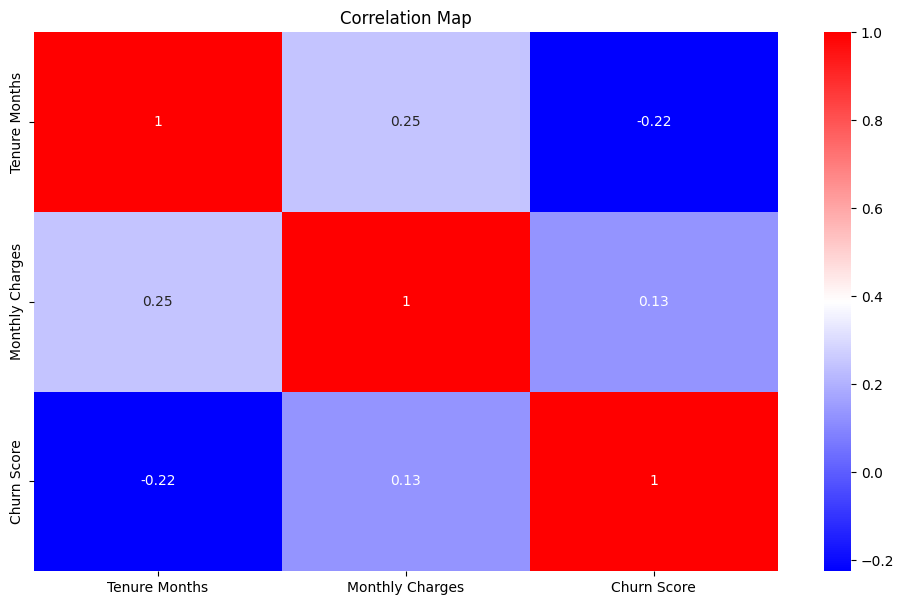

In [360]:
plt.figure(figsize=(12,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="bwr")
plt.title("Correlation Map")

In [361]:
from sklearn.model_selection import train_test_split

In [362]:
df.isnull().sum()

,0
Senior Citizen,0
Partner,0
Dependents,0
Tenure Months,0
Phone Service,0
Multiple Lines,0
Internet Service,0
Online Security,0
Online Backup,0
Device Protection,0


In [363]:
df["Senior Citizen"].unique()

array(['No', 'Yes'], dtype=object)

In [364]:
df["Senior Citizen"] = df["Senior Citizen"].replace(0, "No")
df["Senior Citizen"] = df["Senior Citizen"].replace(1, "Yes")

In [365]:
df["Partner"].unique()

array(['No', 'Yes'], dtype=object)

In [366]:
df["Partner"] = df["Partner"].replace("Yes", 1)
df["Partner"] = df["Partner"].replace("No", 0)

In [367]:
df["Dependents"].unique()

array(['No', 'Yes'], dtype=object)

In [368]:
df["Dependents"] = df["Dependents"].replace("Yes", 1)
df["Dependents"] = df["Dependents"].replace("No", 0)

In [369]:
df["Phone Service"].unique()

array(['Yes', 'No'], dtype=object)

In [370]:
df["Phone Service"] = df["Phone Service"].replace("Yes", 1)
df["Phone Service"] = df["Phone Service"].replace("No", 0)

In [371]:
df["Multiple Lines"].unique()

array(['No', 'Yes', 'No phone service'], dtype=object)

In [372]:
df["Multiple Lines"] = df["Multiple Lines"].replace("Yes", 1)
df["Multiple Lines"] = df["Multiple Lines"].replace("No", 0)
df["Multiple Lines"] = df["Multiple Lines"].replace("No phone service", 2)

In [373]:
df["Internet Service"].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [374]:
df["Internet Service"] = df["Internet Service"].replace("DSL", 1)
df["Internet Service"] = df["Internet Service"].replace("No", 0)
df["Internet Service"] = df["Internet Service"].replace("Fiber Optic", 2)

In [375]:
df["Online Security"].unique()

array(['Yes', 'No', 'No internet service'], dtype=object)

In [376]:
df["Online Security"] = df["Online Security"].replace("Yes", 1)
df["Online Security"] = df["Online Security"].replace("No", 0)
df["Online Security"] = df["Online Security"].replace("No internet service", 2)

In [377]:
df["Online Backup"].unique()

array(['Yes', 'No', 'No internet service'], dtype=object)

In [378]:
df["Online Backup"] = df["Online Backup"].replace("Yes", 1)
df["Online Backup"] = df["Online Backup"].replace("No", 0)
df["Online Backup"] = df["Online Backup"].replace("No internet service", 2)

In [379]:
df["Device Protection"].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [380]:
df["Device Protection"] = df["Device Protection"].replace("Yes", 1)
df["Device Protection"] = df["Device Protection"].replace("No", 0)
df["Device Protection"] = df["Device Protection"].replace("No internet service", 2)

In [381]:
df["Tech Support"].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [382]:
df["Tech Support"] = df["Tech Support"].replace("Yes", 1)
df["Tech Support"] = df["Tech Support"].replace("No", 0)
df["Tech Support"] = df["Tech Support"].replace("No internet service", 2)

In [383]:
df["Streaming TV"].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [384]:
df["Streaming TV"] = df["Streaming TV"].replace("Yes", 1)
df["Streaming TV"] = df["Streaming TV"].replace("No", 0)
df["Streaming TV"] = df["Streaming TV"].replace("No internet service", 2)

In [385]:
df["Streaming Movies"].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [386]:
df["Streaming Movies"] = df["Streaming Movies"].replace("Yes", 1)
df["Streaming Movies"] = df["Streaming Movies"].replace("No", 0)
df["Streaming Movies"] = df["Streaming Movies"].replace("No internet service", 2)

In [387]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

In [388]:
df['Contract'] = df['Contract'].replace('Month-to-month', 1)
df['Contract'] = df['Contract'].replace('One year', 2)
df['Contract'] = df['Contract'].replace('Two year', 3)

In [389]:
df['Paperless Billing'].unique()

array(['Yes', 'No'], dtype=object)

In [390]:
df['Paperless Billing'] = df['Paperless Billing'].replace('Yes', 1)
df['Paperless Billing'] = df['Paperless Billing'].replace('No', 0)

In [391]:
df["Payment Method"].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [392]:
df["Payment Method"] = df["Payment Method"].replace("Electronic check", 1)
df["Payment Method"] = df["Payment Method"].replace("Mailed check", 2)
df["Payment Method"] = df["Payment Method"].replace("Bank transfer (automatic)", 3)
df["Payment Method"] = df["Payment Method"].replace("Credit card (automatic)", 4)

Text(0.5, 1.0, 'Correlation Map')

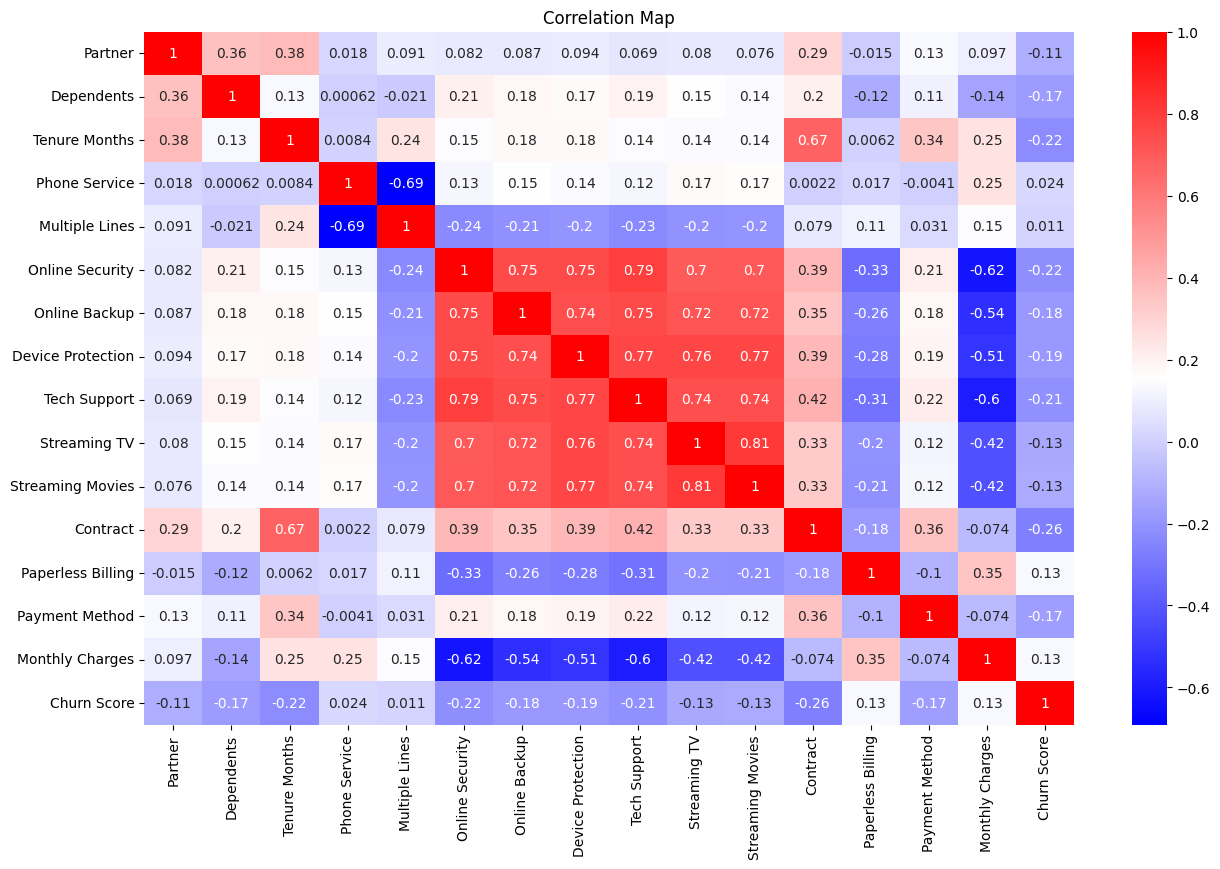

In [393]:
plt.figure(figsize=(15,9))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="bwr")
plt.title("Correlation Map")

In [394]:
df.isnull().sum()

,0
Senior Citizen,0
Partner,0
Dependents,0
Tenure Months,0
Phone Service,0
Multiple Lines,0
Internet Service,0
Online Security,0
Online Backup,0
Device Protection,0


Text(0.5, 1.0, 'Correlation Map')

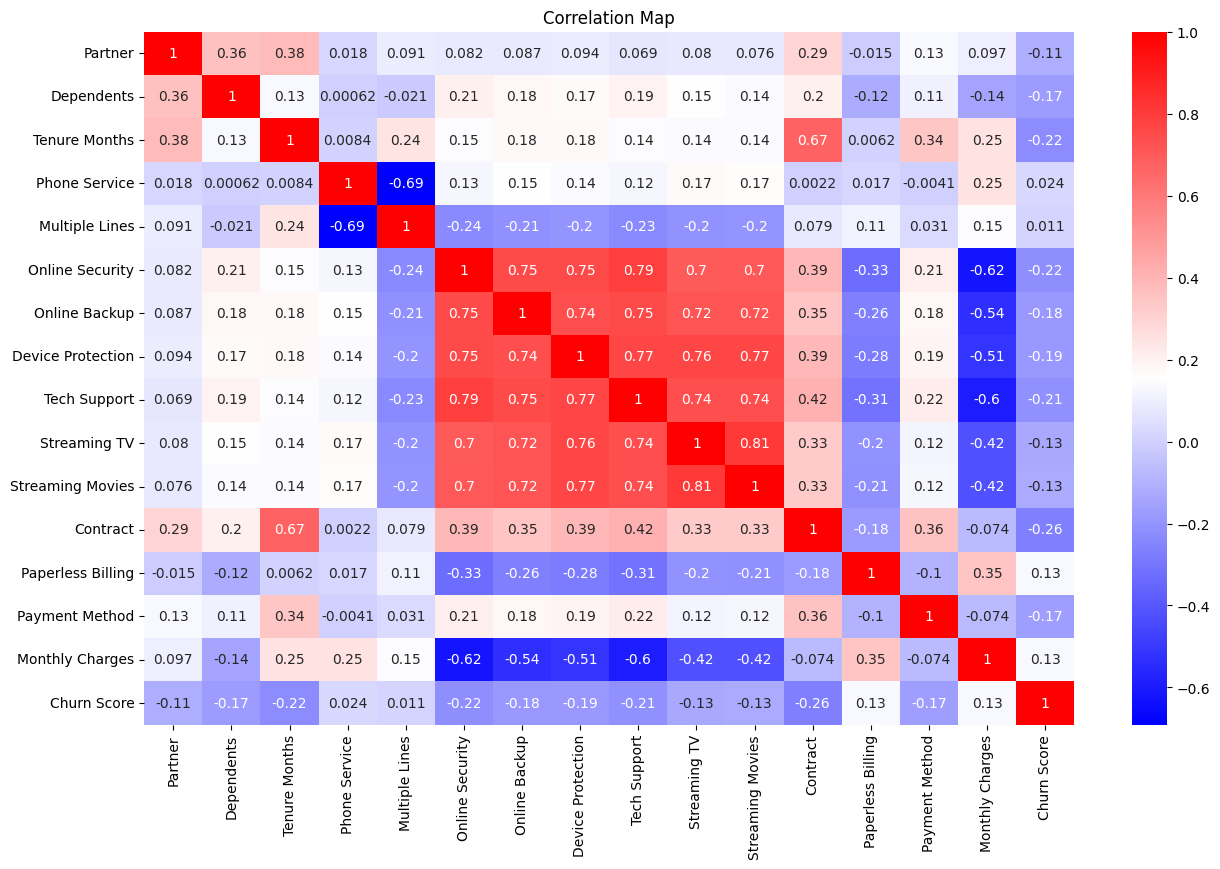

In [395]:
plt.figure(figsize=(15,9))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="bwr")
plt.title("Correlation Map")

In [396]:
df.columns

Index(['Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Score'],
      dtype='object')

In [397]:
from sklearn.model_selection import train_test_split
feature_cols = ['Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Tenure Months',
       'Total Charges']
X = df[feature_cols]
y = df['Churn Score']

In [398]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [399]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [400]:
log_clf = LogisticRegression()
rnd_clf = RandomForestClassifier()
svm_clf = SVC()

In [401]:
voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rnd_clf), ('svc', svm_clf)],
    voting='hard'
)
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression()),
                             ('rf', RandomForestClassifier()), ('svc', SVC())])

In [402]:
from sklearn.metrics import accuracy_score

for clf in (log_clf, rnd_clf, svm_clf, voting_clf):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__.__name__, accuracy_score(y_test, y_pred))

LogisticRegression 0.864
RandomForestClassifier 0.904
SVC 0.896
VotingClassifier 0.904


In [403]:
import pandas as pd

results_df = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Label': y_pred
})

# Assuming 'df_trained_data' is your DataFrame containing trained data
results_df.to_csv('results.csv', index=False)

In [404]:
# model is already trained
import joblib
from joblib import dump

dump(voting_clf, "churn_model.pkl")
dump(scalar, "scaler.pkl")   # if used

['scaler.pkl']